In [7]:
### Simple Multi agent
import os
from typing_extensions import Annotated,TypedDict
from langchain_core.messages import BaseMessage , SystemMessage ,HumanMessage, AIMessage
from typing_extensions import List,Any
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [6]:
from langgraph.prebuilt import ToolNode

In [8]:
class state(MessagesState):
    next_agent :str ## Which agent should go next

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [12]:
@tool
def search_web(query :str) -> str:
    """write a summary to the provided content"""
    search = TavilySearchResults(max_results=2)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content:str) -> str:
    """write a summary for the given content"""
    summary = f"summary of findings\n\n{content[:500]}"
    return summary

In [13]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020033AB56A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020033AB63C0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [14]:
def researcher_agent(state:state):
    """researcher agent that searcher for information"""
    messages = state['messages']
    
    system_msg = SystemMessage(content="you are a researcher agent use the search_web tool and find the required information")
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg]+messages)
    
    return {
        "messages" : [response],
        "next_agent" : "writer"
    }

In [15]:
def writer_agent(state:state):
    """writer agent that creates summaries"""
    messages = state["messages"]
    
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings. ")
    response = llm.invoke([system_msg]+messages)
    return {
        "messages":[response],
        "next_agent":"end"
    }

In [16]:
def execute_tools(state:state):
    """execute tools will execute the tools"""
    messages = state["messages"]
    last_msg = messages[-1]
    
    if hasattr(last_msg,"tool_calls") and last_msg.tool_calls:
        tool_node = ToolNode([search_web,write_summary])
        response = tool_node.invoke(state)
        return response
    return state

In [18]:
workflow = StateGraph(state)

workflow.add_node("researcher_agent",researcher_agent)
workflow.add_node("writer_agent",writer_agent)

workflow.set_entry_point("researcher_agent")
workflow.add_edge("researcher_agent","writer_agent")
workflow.add_edge("writer_agent",END)

graph = workflow.compile()

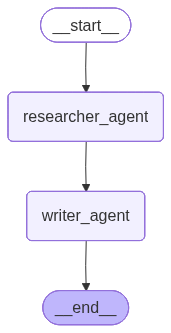

In [19]:
graph